In [2]:
# Import Required Libraries
from pydoc import help  # can type in the python console 'help(name of function)'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy import stats
from IPython.display import display, HTML

In [3]:
data = pd.read_csv('wine_100k_generated.csv',header=0)

In [4]:
data

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,magnesium,potassium,color_intensity,tannin,quality
0,7.248357,0.493087,0.332384,2.456909,0.038829,19.297589,115.792128,0.995230,3.176526,0.477128,8.860975,18.602811,101.209811,3.426016,0.827508,0
1,6.718856,0.449358,0.315712,1.727593,0.032938,24.396946,97.742237,0.995020,3.128763,0.422781,9.033277,16.547019,101.878490,3.819808,0.970831,0
2,6.699147,0.592614,0.299325,1.682687,0.044113,16.337469,102.088636,0.994412,3.133591,0.459843,9.221540,20.514105,99.421759,3.909669,0.852148,0
3,6.640078,0.476968,0.352856,2.103085,0.031185,20.972252,96.149177,0.994797,3.230584,0.501550,9.279384,17.482347,98.453938,4.099379,1.097555,0
4,6.760413,0.490717,0.244683,1.641138,0.044063,24.068720,99.279899,0.995301,3.218082,0.417744,9.108419,24.614110,99.820870,4.469393,0.738025,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,11.884637,0.374705,0.350309,3.366593,0.062133,36.804872,147.268574,0.999245,3.090288,0.560627,11.601829,30.982996,128.849389,9.033513,1.821814,9
99996,11.373299,0.449751,0.404936,3.828027,0.065100,36.245303,147.626075,0.999670,3.083347,0.615033,12.365278,30.034548,133.714586,8.771009,1.988565,9
99997,11.906497,0.355780,0.417861,3.596230,0.058034,36.893159,139.705382,0.999502,3.095702,0.652645,12.058420,35.563995,139.881002,8.695290,1.932262,9
99998,11.451411,0.369533,0.408157,3.091529,0.053824,40.273510,155.423477,0.999069,3.055613,0.735255,11.858374,31.768817,145.540950,8.579687,1.707641,9


In [5]:
#hien thi 5 dong dau tien
data.head(5)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,magnesium,potassium,color_intensity,tannin,quality
0,7.248357,0.493087,0.332384,2.456909,0.038829,19.297589,115.792128,0.995230,3.176526,0.477128,8.860975,18.602811,101.209811,3.426016,0.827508,0
1,6.718856,0.449358,0.315712,1.727593,0.032938,24.396946,97.742237,0.995020,3.128763,0.422781,9.033277,16.547019,101.878490,3.819808,0.970831,0
2,6.699147,0.592614,0.299325,1.682687,0.044113,16.337469,102.088636,0.994412,3.133591,0.459843,9.221540,20.514105,99.421759,3.909669,0.852148,0
3,6.640078,0.476968,0.352856,2.103085,0.031185,20.972252,96.149177,0.994797,3.230584,0.501550,9.279384,17.482347,98.453938,4.099379,1.097555,0
4,6.760413,0.490717,0.244683,1.641138,0.044063,24.068720,99.279899,0.995301,3.218082,0.417744,9.108419,24.614110,99.820870,4.469393,0.738025,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   fixed_acidity         100000 non-null  float64
 1   volatile_acidity      100000 non-null  float64
 2   citric_acid           100000 non-null  float64
 3   residual_sugar        100000 non-null  float64
 4   chlorides             100000 non-null  float64
 5   free_sulfur_dioxide   100000 non-null  float64
 6   total_sulfur_dioxide  100000 non-null  float64
 7   density               100000 non-null  float64
 8   pH                    100000 non-null  float64
 9   sulphates             100000 non-null  float64
 10  alcohol               100000 non-null  float64
 11  magnesium             100000 non-null  float64
 12  potassium             100000 non-null  float64
 13  color_intensity       100000 non-null  float64
 14  tannin                100000 non-null  float64
 15  q

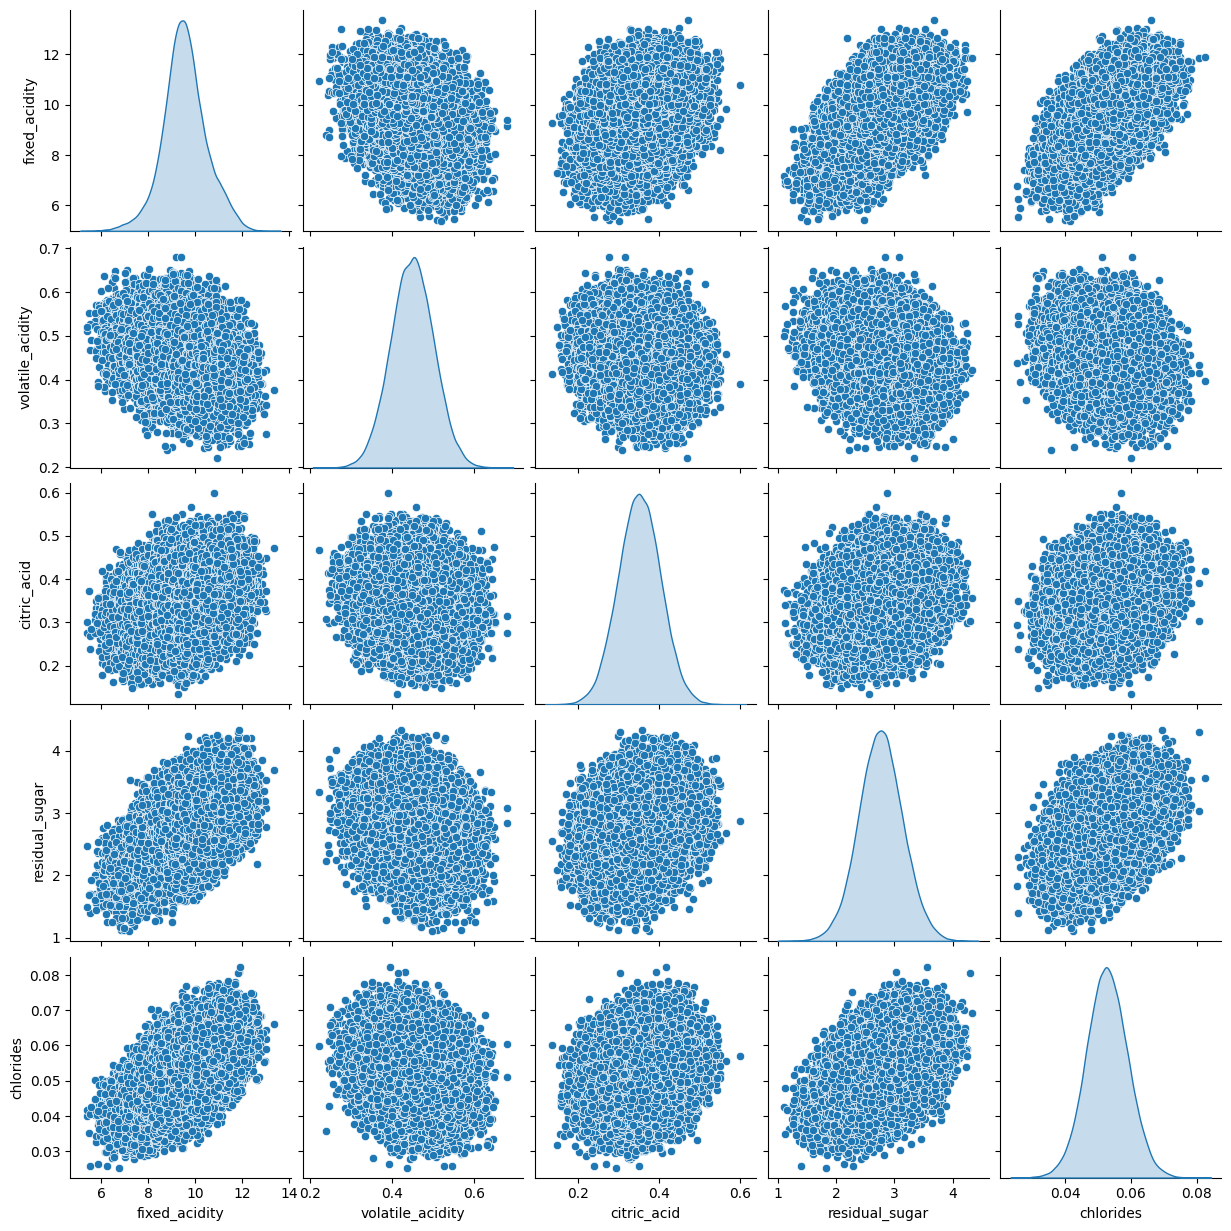

'\ntrả lời đc: chat trên đường chéo thể hiện điều gì\nchart không nằm trên đường chéo thể hiện gì\nkết luận gì về phân phối các biến định lượng và tương quan\n'

In [7]:
#trực quan phân phối và tương quan các biến định lượng (fixed_acidity - tannin)
sns.pairplot(data.loc[:,"fixed_acidity":"chlorides"],diag_kind='kde')
plt.show()
'''
trả lời đc: chat trên đường chéo thể hiện điều gì
chart không nằm trên đường chéo thể hiện gì
kết luận gì về phân phối các biến định lượng và tương quan
'''


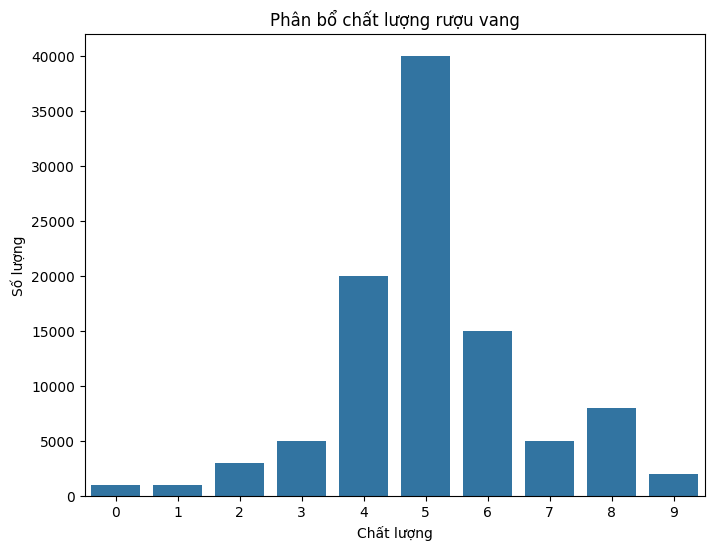

In [8]:
# Phân tích phân bổ của biến mục tiêu 'quality'
plt.figure(figsize=(8, 6))
sns.countplot(x='quality', data=data)
plt.title('Phân bổ chất lượng rượu vang')
plt.xlabel('Chất lượng')
plt.ylabel('Số lượng')
plt.show()

In [9]:
#phân tích về phân phối
#độ xiên:xiên phải,xiên trái,ko xiên
data.loc[:,"fixed_acidity":"residual_sugar"].skew()

#độ nhọn
data.loc[:,"fixed_acidity":"residual_sugar"].kurtosis()

fixed_acidity       0.566999
volatile_acidity    0.011196
citric_acid         0.000276
residual_sugar      0.140281
dtype: float64

In [10]:
#phân tích tương quan tuyến tính pearson
#tương quan gì
# mức độ tương quan
data.loc[:,"fixed_acidity":"residual_sugar"].corr()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar
fixed_acidity,1.000000,-0.254777,0.247016,0.519605
volatile_acidity,-0.254777,1.000000,-0.095117,-0.186438
citric_acid,0.247016,-0.095117,1.000000,0.178458
residual_sugar,0.519605,-0.186438,0.178458,1.000000


'\ncái sự phân bổ, được chưa,giữa những nhóm loại rượu v4 v5 có sự phân chia rõ ràng:\nv4 trong nhóm 2 thấp hơn v4 trong nhóm 1,sự khác biệt rất rõ ràng luôn,v3 nằm xen kẽ giữa 2 thằng đó\nnếu chỉ sử dụng v4 để xd mô hình phân lớp cho loại rượu thì nó sẽ phân lớp rất tốt trên 2 nhóm 1 và 2,nhưng trên \nnhóm 3 thì khó: bị nhập nhằng giữa nhóm 1 và 2(xa rời nhóm 1 nhập nhằng nhóm 2)\n'

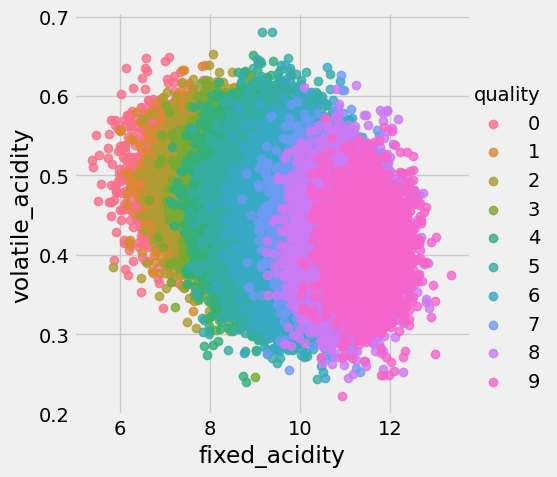

In [85]:
#phân tihcs sâu vào từng cặp biến trên các nhãn mục tiêu.giả sử(V4,V5) trên biến mục tiêu V1
sns.lmplot(x="fixed_acidity",y="volatile_acidity",data=data,hue="quality",fit_reg=False)
#từ biểu đồ nhận xét được cái gì
'''
cái sự phân bổ, được chưa,giữa những nhóm loại rượu v4 v5 có sự phân chia rõ ràng:
v4 trong nhóm 2 thấp hơn v4 trong nhóm 1,sự khác biệt rất rõ ràng luôn,v3 nằm xen kẽ giữa 2 thằng đó
nếu chỉ sử dụng v4 để xd mô hình phân lớp cho loại rượu thì nó sẽ phân lớp rất tốt trên 2 nhóm 1 và 2,nhưng trên 
nhóm 3 thì khó: bị nhập nhằng giữa nhóm 1 và 2(xa rời nhóm 1 nhập nhằng nhóm 2)
'''

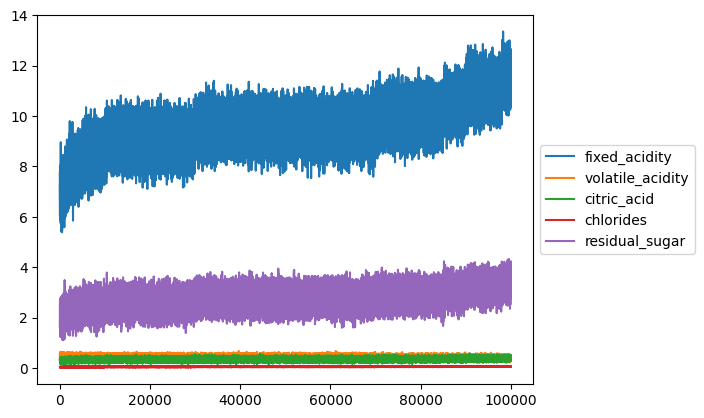

In [14]:
# phân tích profile bao gồm giá trị trung bình,độ lệch chuẩn(mức độ phân tán) của các biến số định lượng
ax=data[["fixed_acidity","volatile_acidity","citric_acid","chlorides","residual_sugar"]].plot()
ax.legend(loc='center left',bbox_to_anchor=(1,0.5));

In [15]:
#thống kê mô tả dữ liệu
data[["fixed_acidity","volatile_acidity","citric_acid","chlorides","residual_sugar"]].describe()
#buồn buồn thì mr.nam hỏi
# 50% số lượng dữ liệu của V4 có giá trị nhỏ hơn bao nhiêu
# so sánh mức độ biến động của dữ liệu giữa các biến số
# gợi ý: tính giá trị coefficient of variation(CV)

,fixed_acidity,volatile_acidity,citric_acid,chlorides,residual_sugar
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,9.545368,0.449196,0.350714,0.052722,2.762583
std,0.932472,0.052428,0.052347,0.006353,0.382012
min,5.389492,0.222001,0.134027,0.025353,1.109974
25%,8.980593,0.413890,0.315452,0.048510,2.508733
50%,9.514838,0.449348,0.350704,0.052668,2.760749
75%,10.095654,0.484578,0.386047,0.056925,3.013879
max,13.356764,0.680819,0.598264,0.082370,4.330761


In [16]:
#thống kê mô tả số liệu bién định lượng trên nhóm là biến mục tiêu
groups=data[["quality","fixed_acidity","volatile_acidity"]].groupby('quality')
groups.describe().T


quality                           0            1            2            3  \
fixed_acidity    count  1000.000000  1000.000000  3000.000000  5000.000000   
                 mean      6.990500     7.486636     7.998589     8.491417   
                 std       0.518268     0.510427     0.502368     0.503574   
                 min       5.389492     6.011984     5.852305     6.647425   
                 25%       6.646862     7.137800     7.667619     8.155944   
                 50%       6.998094     7.489128     8.000934     8.493080   
                 75%       7.330113     7.832498     8.334839     8.823552   
                 max       8.963119     9.068343     9.801208    10.352622   
volatile_acidity count  1000.000000  1000.000000  3000.000000  5000.000000   
                 mean      0.499585     0.491029     0.479461     0.470747   
                 std       0.051032     0.047597     0.050537     0.049513   
                 min       0.333525     0.329352     0.307598     0.246852   
                 25%       0.464146     0.459690     0.445270     0.437755   
                 50%       0.499325     0.488947     0.478922     0.470346   
                 75%       0.533283     0.522553     0.513554     0.503719   
                 max       0.649263     0.638064     0.652311     0.630436   

quality                            4             5             6            7  \
fixed_acidity    count  20000.000000  40000.000000  15000.000000  5000.000000   
                 mean       9.004592      9.498349     10.001410    10.496702   
                 std        0.501161      0.499295      0.500226     0.498952   
                 min        7.108398      7.535583      8.015321     8.708720   
                 25%        8.668885      9.161896      9.664534    10.164900   
                 50%        9.005133      9.495943     10.000412    10.496738   
                 75%        9.337716      9.834327     10.334278    10.837025   
                 max       10.887652     11.402195     11.928858    12.125096   
volatile_acidity count  20000.000000  40000.000000  15000.000000  5000.000000   
                 mean       0.460469      0.449846      0.440324     0.430369   
                 std        0.050059      0.050093      0.049905     0.049723   
                 min        0.239789      0.243416      0.245388     0.252996   
                 25%        0.426008      0.416277      0.406929     0.396785   
                 50%        0.460837      0.449618      0.440429     0.429551   
                 75%        0.494815      0.483748      0.473697     0.464095   
                 max        0.651250      0.680819      0.639039     0.626383   

quality                           8            9  
fixed_acidity    count  8000.000000  2000.000000  
                 mean     11.009023    11.502090  
                 std       0.504498     0.496664  
                 min       9.254584    10.017416  
                 25%      10.661770    11.160066  
                 50%      11.009647    11.505405  
                 75%      11.349234    11.837383  
                 max      12.859865    13.356764  
volatile_acidity count  8000.000000  2000.000000  
                 mean      0.419624     0.409950  
                 std       0.049772     0.050661  
                 min       0.245232     0.222001  
                 25%       0.386074     0.375648  
                 50%       0.419668     0.409509  
                 75%       0.453503     0.445129  
                 max       0.614445     0.571692

In [17]:
#đánh giá sự thay đổi biến thiên(variance) giữ các nhóm(mục tiêu) trong biến định lượng
# ví dụ: hãy cho biết sự khác biệt về dữ liệu trên nhóm v1 của biến v2 và v4 cái nào cao
# giá trị tính ra càng cao thì trên nhóm có sự thay đổi dữ liệu rất lớn
def calcWithinGroupsVariance(variable, groupvariable):
    # Tìm ra các nhóm trong biến phân loại
    levels = sorted(set(groupvariable))
    numlevels = len(levels)

    # Khởi tạo biến tổng tử số và mẫu số
    numtotal = 0
    denomtotal = 0

    # Lặp qua từng nhóm
    for leveli in levels:
        # Lấy dữ liệu thuộc nhóm i
        levelidata = variable[groupvariable == leveli]
        levelilength = len(levelidata)

        # Tính độ lệch chuẩn (std) của nhóm i
        sdi = np.std(levelidata)

        # Bình phương std → phương sai nhóm i
        # Nhân với số phần tử trong nhóm
        numi = (levelilength) * sdi**2

        # Cộng dồn
        denomi = levelilength
        numtotal = numtotal + numi
        denomtotal = denomtotal + denomi

    # Tính phương sai trong nhóm (within groups variance)
    Vw = numtotal / (denomtotal - numlevels)
    return Vw

In [18]:
calcWithinGroupsVariance(data.fixed_acidity,data.quality)

np.float64(0.2507686720365047)

In [19]:
calcWithinGroupsVariance(data.citric_acid,data.quality)

np.float64(0.0025040356421693177)

In [20]:
#phương sai giữa các nhóm trong 1 biến
def calcBetweenGroupsVariance(variable, groupvariable):
    # tìm các nhóm có trong biến phân loại
    levels = sorted(set(groupvariable))
    numlevels = len(levels)

    # grand mean: trung bình toàn bộ dữ liệu
    grandmean = np.mean(variable)

    # khởi tạo biến cộng dồn
    numtotal = 0
    denomtotal = 0

    for leveli in levels:
        # dữ liệu thuộc nhóm i
        levelidata = variable[groupvariable == leveli]
        levelilength = len(levelidata)

        # mean và std của nhóm i
        meani = np.mean(levelidata)
        sdi = np.std(levelidata)

        # phần tử trong công thức: n_i * (mean_i - grandmean)^2
        numi = levelilength * ((meani - grandmean) ** 2)

        # cộng dồn
        denomi = levelilength
        numtotal = numtotal + numi
        denomtotal = denomtotal + denomi

    # phương sai giữa các nhóm
    Vb = numtotal / (numlevels - 1)
    return Vb

In [21]:
calcBetweenGroupsVariance(data.fixed_acidity,data.quality)

np.float64(6875.018570721648)

In [22]:
calcBetweenGroupsVariance(data.citric_acid,data.quality)

np.float64(2.62632593795912)

In [23]:
def calcSeparations(variables, groupvariable):
    # calculate the separation for each variable
    for variablename in variables:
        variablei = variables[variablename]

        Vw = calcWithinGroupsVariance(variablei, groupvariable)
        Vb = calcBetweenGroupsVariance(variablei, groupvariable)

        sep = Vb / Vw
        print("variable", variablename, "Vw=", Vw, "Vb=", Vb, "separation=", sep)





In [24]:
# Gọi hàm cho các biến từ V2 đến V14, phân nhóm theo V1
calcSeparations(data.loc[:, "fixed_acidity":"tannin"], data.quality)

variable fixed_acidity Vw= 0.2507686720365047 Vb= 6875.018570721648 separation= 27415.7793112245
variable volatile_acidity Vw= 0.0024994965074756226 Vb= 2.771909062942113 separation= 1108.986971836826
variable citric_acid Vw= 0.0025040356421693177 Vb= 2.62632593795912 separation= 1048.8372823974098
variable residual_sugar Vw= 0.09052424294465926 Vb= 615.7354186633346 separation= 6801.884209512317
variable chlorides Vw= 2.4948271117039706e-05 Vb= 0.17131611726257034 separation= 6866.853276480597
variable free_sulfur_dioxide Vw= 8.955584933124717 Vb= 110160.35116201191 separation= 12300.743277477417
variable total_sulfur_dioxide Vw= 100.36014243119816 Vb= 677969.2319823287 separation= 6755.363389874722
variable density Vw= 9.022183715553385e-08 Vb= 0.006818612667009342 separation= 75576.07871866657
variable pH Vw= 0.0025163100235010396 Vb= 2.6567699650631473 separation= 1055.819807674843
variable sulphates Vw= 0.00250549111900898 Vb= 10.859432266139734 separation= 4334.252946957188
varia

In [25]:
#hiệp phương sai trong nhóm cho 2 biến
# hiệp phương sai dùng để xét tương quan giữa các biến số(tương quan đồng biến và tương quan nghịch biến)
def calcWithinGroupsCovariance(variable1, variable2, groupvariable):
    levels = sorted(set(groupvariable))
    numlevels = len(levels)
    Covw = 0.0
    total_length = 0

    for leveli in levels:
        # lấy dữ liệu của group i
        levelidata1 = variable1[groupvariable == leveli]
        levelidata2 = variable2[groupvariable == leveli]

        n = len(levelidata1)
        mean1 = np.mean(levelidata1)
        mean2 = np.mean(levelidata2)

        # tính covariance trong group i
        cov_i = np.sum((levelidata1 - mean1) * (levelidata2 - mean2))
        
        Covw += cov_i
        total_length += n

    # chia cho (tổng quan sát - số nhóm)
    Covw /= (total_length - numlevels)
    return Covw

In [26]:
calcWithinGroupsCovariance(data.alcohol, data.color_intensity, data.quality)
#nhận xét 

np.float64(-0.0001062956401131531)

In [27]:
#hiệp phương sai giữa các nhóm
def calcBetweenGroupsCovariance(variable1, variable2, groupvariable):
    # danh sách các nhóm
    levels = sorted(set(groupvariable))
    numlevels = len(levels)

    # grand means (trung bình toàn cục)
    variable1_mean = np.mean(variable1)
    variable2_mean = np.mean(variable2)

    # tính covariance giữa các nhóm
    Covb = 0.0
    for leveli in levels:
        levelidata1 = variable1[groupvariable == leveli]
        levelidata2 = variable2[groupvariable == leveli]

        mean1 = np.mean(levelidata1)
        mean2 = np.mean(levelidata2)
        n = len(levelidata1)

        termi = (mean1 - variable1_mean) * (mean2 - variable2_mean) * n
        Covb += termi

    Covb /= (numlevels - 1)
    return Covb

In [28]:
calcBetweenGroupsCovariance(data.alcohol, data.color_intensity, data.quality)

np.float64(4101.808823559913)

In [29]:
#kiểm định tương quan (install scipy)

from scipy import stats

#Kiểm định tương quan Pearson hai biến định lượng 
corr = stats.pearsonr(data.fixed_acidity,data.volatile_acidity) 
print ("p-value:\t", corr [1])
print ("cor:\t\t", corr[0])

p-value:	 0.0
cor:		 -0.2547769642341221


In [30]:
#Ma trận tương quan Pearson
corrmat = data.corr()
corrmat

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,magnesium,potassium,color_intensity,tannin,quality
fixed_acidity,1.000000,-0.254777,0.247016,0.519605,0.521480,0.611858,0.516503,0.786939,-0.248772,0.446897,0.710692,0.520034,0.661256,0.787754,0.711393,0.843567
volatile_acidity,-0.254777,1.000000,-0.095117,-0.186438,-0.187107,-0.217703,-0.182931,-0.281825,0.093387,-0.159175,-0.256076,-0.185932,-0.236418,-0.281352,-0.252414,-0.301192
citric_acid,0.247016,-0.095117,1.000000,0.178458,0.182278,0.216034,0.180097,0.274943,-0.086865,0.154118,0.246653,0.179525,0.232452,0.273908,0.247639,0.293628
residual_sugar,0.519605,-0.186438,0.178458,1.000000,0.380277,0.444095,0.377355,0.575691,-0.181649,0.330032,0.518658,0.376471,0.482901,0.575049,0.521643,0.616214
chlorides,0.521480,-0.187107,0.182278,0.380277,1.000000,0.444827,0.380696,0.578093,-0.184480,0.324382,0.521188,0.380754,0.483258,0.576180,0.520379,0.618027
free_sulfur_dioxide,0.611858,-0.217703,0.216034,0.444095,0.444827,1.000000,0.446480,0.677740,-0.212528,0.385518,0.611910,0.444721,0.569203,0.677031,0.610477,0.724831
total_sulfur_dioxide,0.516503,-0.182931,0.180097,0.377355,0.380696,0.446480,1.000000,0.573215,-0.185034,0.331009,0.516537,0.379892,0.482390,0.574170,0.519605,0.614904
density,0.786939,-0.281825,0.274943,0.575691,0.578093,0.677740,0.573215,1.000000,-0.275925,0.493216,0.786207,0.573834,0.731759,0.871749,0.788208,0.933714
pH,-0.248772,0.093387,-0.086865,-0.181649,-0.184480,-0.212528,-0.185034,-0.275925,1.000000,-0.157798,-0.249030,-0.183130,-0.227439,-0.277158,-0.250464,-0.294510
sulphates,0.446897,-0.159175,0.154118,0.330032,0.324382,0.385518,0.331009,0.493216,-0.157798,1.000000,0.447712,0.323185,0.413168,0.494423,0.444069,0.529692


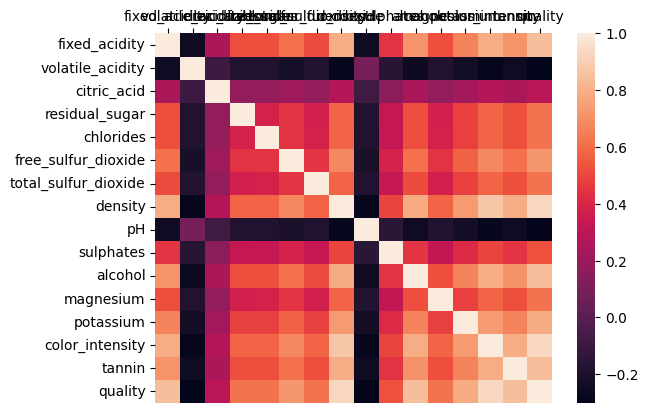

In [31]:
#Heat Map trực quan tương quan
sns.heatmap(corrmat, vmax=1, square=False).xaxis.tick_top()

In [32]:
def mostHighlyCorrelated(mydataframe, numtoreport):
    # Find the correlations
    corrmat = mydataframe.corr()
    # Set the correlations on the diagonal or lower triangle to zero
    corrmat.values[np.tril_indices_from(corrmat, k=0)] = 0
    # Find the top correlations
    corr_pairs = corrmat.stack().sort_values(ascending=False).reset_index()
    # Đặt tên cột cho dễ hiểu
    corr_pairs.columns = ["FirstVariable", "SecondVariable", "Correlation"]
    return corr_pairs.head(numtoreport)

In [33]:
mostHighlyCorrelated(data, 10)

,FirstVariable,SecondVariable,Correlation
0,color_intensity,quality,0.933889
1,density,quality,0.933714
2,density,color_intensity,0.871749
3,fixed_acidity,quality,0.843567
4,tannin,quality,0.843299
5,alcohol,quality,0.842576
6,density,tannin,0.788208
7,color_intensity,tannin,0.787755
8,fixed_acidity,color_intensity,0.787754
9,fixed_acidity,density,0.786939


In [34]:
from sklearn.preprocessing import scale

# Chuẩn hóa dữ liệu số
X = data.iloc[:, :-1]
X = X.apply(pd.to_numeric, errors='coerce')  # chuyển về số, loại bỏ giá trị không phải số
standardisedX = scale(X)
standardisedX = pd.DataFrame(standardisedX, columns=X.columns, index=X.index)


In [35]:
standardisedX.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,magnesium,potassium,color_intensity,tannin
count,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,100000.000000,1.000000e+05
mean,-2.546585e-16,-1.691660e-15,-1.818989e-17,-2.182787e-16,1.309672e-15,-9.458745e-16,-4.001777e-16,1.324224e-14,5.347829e-15,1.346052e-15,-2.037268e-15,2.182787e-16,5.456968e-16,0.000000,5.456968e-16
std,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005,1.000005e+00
min,-4.456860e+00,-4.333444e+00,-4.139489e+00,-4.326091e+00,-4.307817e+00,-5.051242e+00,-4.909902e+00,-4.188346e+00,-4.595377e+00,-4.655292e+00,-4.793040e+00,-4.621734e+00,-4.769195e+00,-4.103674,-4.480814e+00
25%,-6.056777e-01,-6.734125e-01,-6.736412e-01,-6.645106e-01,-6.629524e-01,-6.469843e-01,-6.589713e-01,-5.563895e-01,-6.724704e-01,-6.678595e-01,-6.090244e-01,-6.622945e-01,-6.310866e-01,-0.558720,-6.073070e-01
50%,-3.274140e-02,2.904737e-03,-1.901559e-04,-4.800058e-03,-8.501580e-03,-1.869045e-02,-4.271452e-03,-4.722992e-02,-3.266341e-04,-6.020669e-03,-3.300318e-02,-6.304441e-03,-1.812310e-02,-0.048095,-3.442210e-02
75%,5.901393e-01,6.748788e-01,6.749763e-01,6.578276e-01,6.616165e-01,6.425921e-01,6.575759e-01,5.126972e-01,6.739828e-01,6.657273e-01,5.897937e-01,6.607286e-01,6.195902e-01,0.513087,5.882629e-01
max,4.087431e+00,4.417918e+00,4.729057e+00,4.105076e+00,4.666635e+00,4.100737e+00,4.652896e+00,3.477038e+00,3.941633e+00,4.378209e+00,3.902433e+00,4.190592e+00,4.190977e+00,3.643232,3.911626e+00


In [36]:
standardisedX.apply(np.mean)

fixed_acidity          -2.546585e-16
volatile_acidity       -1.691660e-15
citric_acid            -1.818989e-17
residual_sugar         -2.182787e-16
chlorides               1.309672e-15
free_sulfur_dioxide    -9.458745e-16
total_sulfur_dioxide   -4.001777e-16
density                 1.324224e-14
pH                      5.347829e-15
sulphates               1.346052e-15
alcohol                -2.037268e-15
magnesium               2.182787e-16
potassium               5.456968e-16
color_intensity         0.000000e+00
tannin                  5.456968e-16
dtype: float64

In [37]:
standardisedX.apply(np.std)


fixed_acidity           1.0
volatile_acidity        1.0
citric_acid             1.0
residual_sugar          1.0
chlorides               1.0
free_sulfur_dioxide     1.0
total_sulfur_dioxide    1.0
density                 1.0
pH                      1.0
sulphates               1.0
alcohol                 1.0
magnesium               1.0
potassium               1.0
color_intensity         1.0
tannin                  1.0
dtype: float64

In [38]:
pca = PCA().fit(standardisedX)

In [39]:
def pca_summary(pca, standardised_data, out=True):
    names = ["PC" + str(i) for i in range(1, len(pca.explained_variance_ratio_) + 1)]
    a = list(np.std(pca.transform(standardised_data), axis=0))
    b = list(pca.explained_variance_ratio_)
    c = [np.sum(pca.explained_variance_ratio_[:i]) for i in range(1, len(pca.explained_variance_ratio_) + 1)]
    columns = pd.MultiIndex.from_tuples([
        ("sdev", "Standard deviation"),
        ("varprop", "Proportion of Variance"),
        ("cumprop", "Cumulative Proportion")
    ])
    summary = pd.DataFrame(zip(a, b, c), index=names, columns=columns)
    
    if out:
        print("Importance of components:")
        display(summary)
    
    return summary

summary = pca_summary(pca, standardisedX)

Importance of components:


,sdev,varprop,cumprop
,Standard deviation,Proportion of Variance,Cumulative Proportion
PC1,2.732855,0.497900,0.497900
PC2,0.955827,0.060907,0.558807
PC3,0.950397,0.060217,0.619024
PC4,0.948695,0.060001,0.679025
PC5,0.841915,0.047255,0.726280
PC6,0.790012,0.041608,0.767888
PC7,0.787273,0.041320,0.809208
PC8,0.786058,0.041192,0.850400
PC9,0.740834,0.036589,0.886989


In [40]:
np.sum(summary.sdev**2)

c:\Users\Khanh Duy\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:84: FutureWarning:

The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)



Standard deviation    15.0
dtype: float64

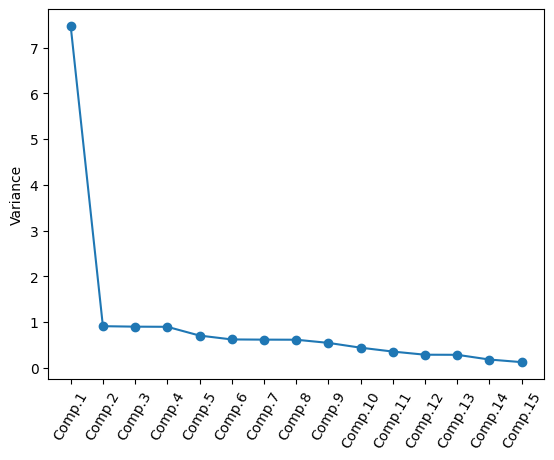

In [41]:
def screeplot(pca, standardised_values):
    y = np.std(pca.transform(standardised_values), axis=0)**2
    x = np.arange(len(y)) + 1
    plt.plot(x, y, "o-")
    plt.xticks(x, ["Comp." + str(i) for i in x], rotation=60)
    plt.ylabel("Variance")
    plt.show()

screeplot(pca, standardisedX)


In [42]:
print("Các thành phần chính (vector riêng):")
pca.components_[0]  

Các thành phần chính (vector riêng):


array([ 0.31238352, -0.12240703,  0.1192925 ,  0.23915469,  0.23973914,
        0.27560709,  0.23892075,  0.33827311, -0.12006298,  0.20867248,
        0.31217469,  0.23883209,  0.29428312,  0.33826347,  0.31238371])

In [43]:
np.sum(pca.components_[0]**2)

np.float64(0.9999999999999997)

In [44]:
def calcpcc(variables, loadings):
    # find the number of samples in the data set and the number of variables
    numsamples, numvariables = variables.shape

    # make a vector to store the component
    pc = np.zeros(numsamples)

    # calculate the value of the component for each sample
    for i in range(numsamples):
        valuei = 0
        for j in range(numvariables):
            valueij = variables.iloc[i, j]
            loadingj = loadings[j]
            valuei = valuei + (valueij * loadingj)
        pc[i] = valuei

    return pc

calcpcc(standardisedX, pca.components_[0])

array([-8.35847365, -8.94324274, -9.38163089, ...,  7.49175852,
        6.96323412,  6.54543875], shape=(100000,))

In [45]:
pca.transform(standardisedX)[:,0]

array([-8.35847365, -8.94324274, -9.38163089, ...,  7.49175852,
        6.96323412,  6.54543875], shape=(100000,))

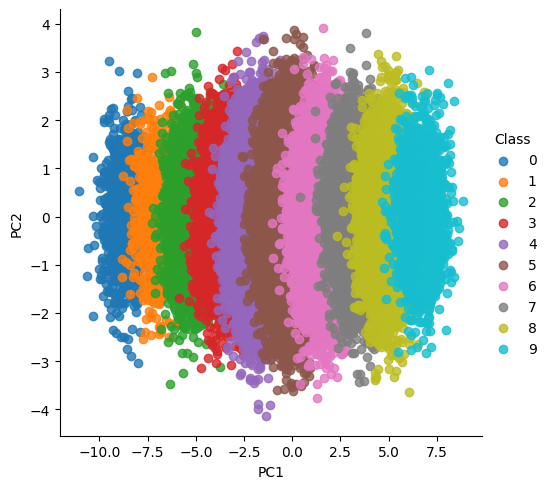

In [46]:
def pca_scatter(pca, standardised_values, classifs):
    foo = pca.transform(standardised_values)
    bar = pd.DataFrame(
        data = {
            'PC1': foo[:, 0],
            'PC2': foo[:, 1],
            'Class': classifs
        }
    )
    sns.lmplot(x="PC1", y="PC2", data=bar, hue="Class", fit_reg=False)

pca_scatter(pca, standardisedX, data.quality)

In [47]:
X_pca_all = pca.transform(standardisedX)

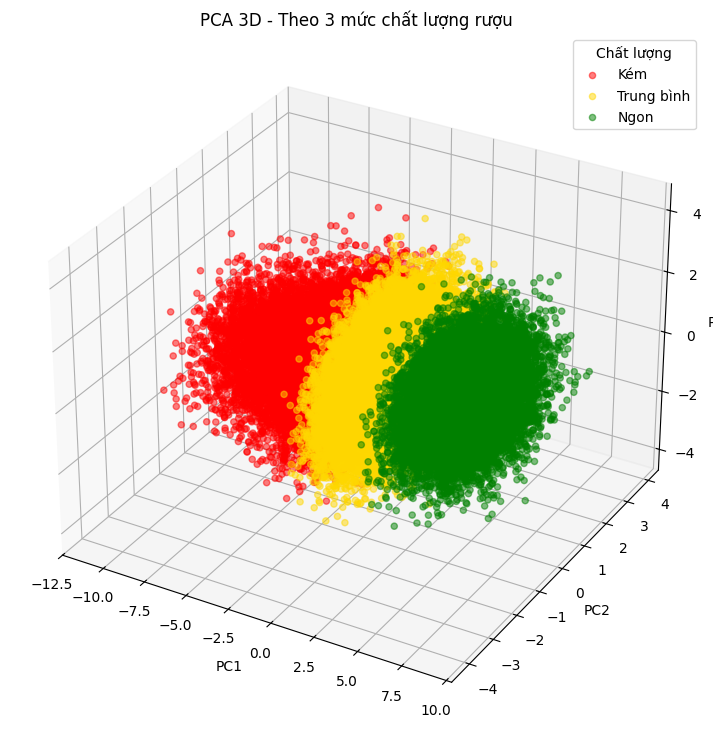

In [48]:
# Trực quan hóa PCA theo 3 mức chất lượng rượu: Kém – Trung bình – Ngon
# Giả sử các mức chất lượng: Kém (quality <= 4), Trung bình (5 <= quality <= 6), Ngon (quality >= 7)

# Tạo nhãn phân loại mới
quality_labels = pd.cut(data['quality'], bins=[-float('inf'), 4, 6, float('inf')], labels=['Kém', 'Trung bình', 'Ngon'])

# PCA đã có: pca_full, X_pca_all
pca_df = pd.DataFrame(X_pca_all[:, :3], columns=['PC1', 'PC2', 'PC3'])
pca_df['Chất lượng'] = quality_labels.values

# Vẽ scatter 3D
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

colors = {'Kém': 'red', 'Trung bình': 'gold', 'Ngon': 'green'}
for label in ['Kém', 'Trung bình', 'Ngon']:
    subset = pca_df[pca_df['Chất lượng'] == label]
    ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'], label=label, color=colors[label], alpha=0.5, s=20)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('PCA 3D - Theo 3 mức chất lượng rượu')
ax.legend(title='Chất lượng')
plt.show()

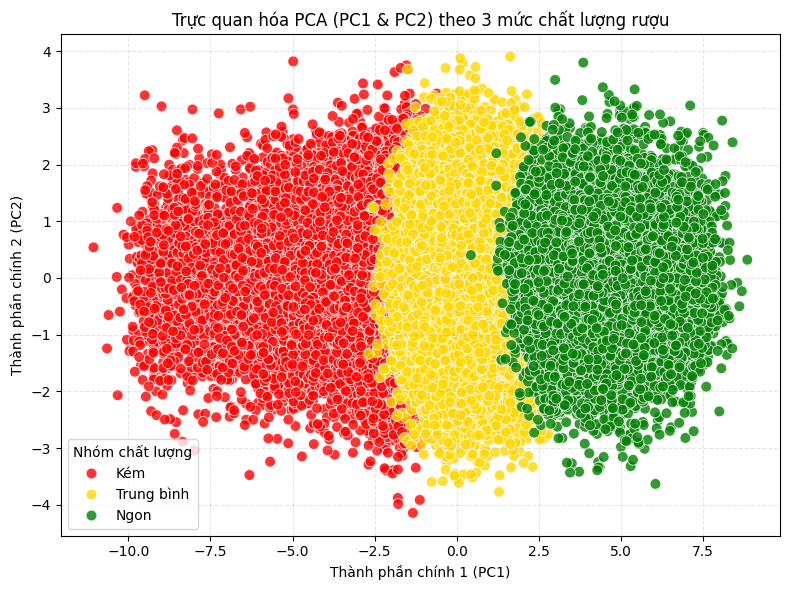

In [49]:
# --- PCA ---
pca = PCA(n_components=2)
pca_data = pca.fit_transform(standardisedX)
df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
df_pca['quality'] = data['quality']

# --- Phân loại chất lượng thành 3 nhóm ---
def classify_quality(q):
    if q <= 4:
        return 'Kém'
    elif q <= 6:
        return 'Trung bình'
    else:
        return 'Ngon'

df_pca['Quality_Class'] = df_pca['quality'].astype(float).apply(classify_quality)
# --- Vẽ biểu đồ PCA theo 3 nhóm chất lượng ---
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_pca,
    x='PC1', y='PC2',
    hue='Quality_Class',
    palette={'Kém':'red', 'Trung bình':'gold', 'Ngon':'green'},
    s=60, alpha=0.8
    )
plt.title('Trực quan hóa PCA (PC1 & PC2) theo 3 mức chất lượng rượu')
plt.xlabel('Thành phần chính 1 (PC1)')
plt.ylabel('Thành phần chính 2 (PC2)')
plt.legend(title='Nhóm chất lượng')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

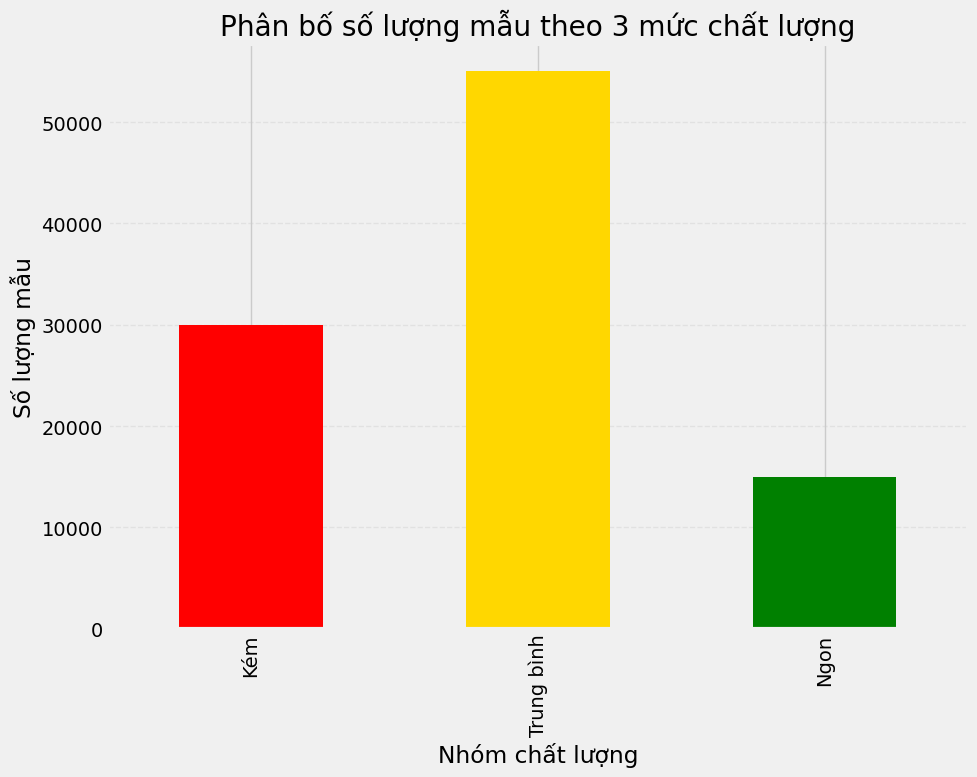

In [91]:
# --- Biểu đồ số lượng mẫu trên từng nhóm chất lượng ---
plt.figure(figsize=(10,8))
df_pca['Quality_Class'].value_counts().reindex(['Kém', 'Trung bình', 'Ngon']).plot(
    kind='bar', color=['red', 'gold', 'green']
)
plt.xlabel('Nhóm chất lượng')
plt.ylabel('Số lượng mẫu')
plt.title('Phân bố số lượng mẫu theo 3 mức chất lượng')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [50]:
from sklearn.cluster import KMeans

In [51]:
kmeans = KMeans(n_clusters=5, random_state=50, n_init= 10, max_iter=100).fit(standardisedX)

In [52]:
print(kmeans.cluster_centers_)
print(kmeans.labels_)

[[-0.07043808  0.01061903 -0.03193751 -0.04000553 -0.05204964 -0.05963613
  -0.04748155 -0.07429136  0.02178305 -0.04013616 -0.06701215 -0.0536302
  -0.06158582 -0.07585981 -0.06791607]
 [ 1.59767963 -0.58931108  0.57070396  1.18718377  1.17783109  1.39132052
   1.18145002  1.74576227 -0.57635231  1.02838166  1.59553263  1.1845149
   1.48629912  1.74660855  1.60042461]
 [ 0.53638179 -0.2326061   0.25073671  0.43690208  0.46162171  0.49499383
   0.44492932  0.56870336 -0.24255902  0.38546764  0.53839046  0.4449954
   0.51907342  0.57151595  0.53411177]
 [-1.90492971  0.7077499  -0.68811784 -1.42276456 -1.4199772  -1.63994087
  -1.41508326 -2.08534685  0.68387696 -1.2351358  -1.89742318 -1.41165605
  -1.79851935 -2.07403688 -1.90022402]
 [-0.68094901  0.30625881 -0.27920344 -0.55821106 -0.55364421 -0.62425519
  -0.55074118 -0.73315578  0.29421429 -0.47911016 -0.68944696 -0.54241216
  -0.65072982 -0.73603826 -0.68609011]]
[3 3 3 ... 1 1 1]


In [53]:
print(kmeans.inertia_)
print(kmeans.n_iter_)

810569.4494072645
34


In [54]:
standardisedX['ClusterLabel'] = kmeans.labels_[:]

In [55]:
standardisedX.head(10)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,magnesium,potassium,color_intensity,tannin,ClusterLabel
0,-2.463369,0.837167,-0.350167,-0.800173,-2.186634,-2.504016,-0.763196,-2.754927,0.524623,-1.267138,-2.981971,-2.370822,-2.380860,-3.712655,-3.661223,3
1,-3.031218,0.003106,-0.668661,-2.709329,-3.113832,-1.330093,-2.184107,-3.005197,-0.385340,-2.188065,-2.673612,-2.911019,-2.297748,-3.243639,-2.891166,3
2,-3.052355,2.735517,-0.981714,-2.826881,-1.355018,-3.185466,-1.841953,-3.730077,-0.293358,-1.560036,-2.336688,-1.868595,-2.603104,-3.136613,-3.528837,3
3,-3.115702,0.529723,0.040913,-1.726389,-3.389859,-2.118492,-2.309515,-3.271395,1.554493,-0.853300,-2.233168,-2.665244,-2.723398,-2.910664,-2.210291,3
4,-2.986652,0.791967,-2.025565,-2.935645,-1.362903,-1.405654,-2.063060,-2.670504,1.316312,-2.273416,-2.539135,-0.791245,-2.553497,-2.469968,-4.142005,3
5,-2.288999,1.052043,-1.254426,-1.924177,-3.566562,-2.494026,-1.725249,-2.500883,0.478142,-2.411837,-3.002556,-1.282070,-2.326924,-3.218313,-2.458668,3
6,-2.677659,1.892809,-1.639405,-2.253559,-2.310944,-3.353062,-1.773263,-2.935996,0.976700,-1.925587,-3.493068,-2.335282,-2.744219,-3.315686,-2.821099,3
7,-2.513056,2.767854,-0.802070,-1.793980,-2.060945,-3.667475,-2.027245,-3.007807,3.318235,-1.889810,-2.571267,-2.031049,-3.257529,-2.620688,-2.330435,3
8,-2.305552,0.101758,0.371090,-3.097141,-1.540503,-0.829520,-2.786136,-3.231839,1.066754,-2.153406,-3.565706,-1.949637,-3.191421,-2.859808,-3.228439,3
9,-1.898620,0.222050,-1.276447,-1.357367,-2.971040,-2.185224,-0.977373,-3.604143,1.147706,-1.506640,-2.313410,-2.978779,-3.351855,-2.842533,-2.574875,3


<Axes: xlabel='ClusterLabel', ylabel='count'>

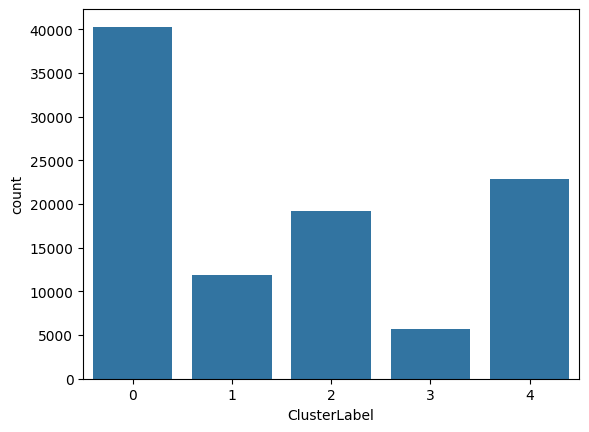

In [56]:
sns.countplot(x=standardisedX['ClusterLabel'])

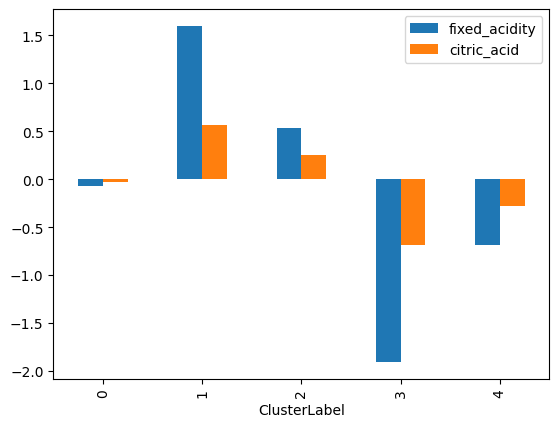

In [57]:
gr_data_mean = standardisedX.groupby(['ClusterLabel'])[['fixed_acidity','citric_acid']].mean()
gr_data_mean.plot(kind='bar')
plt.show()

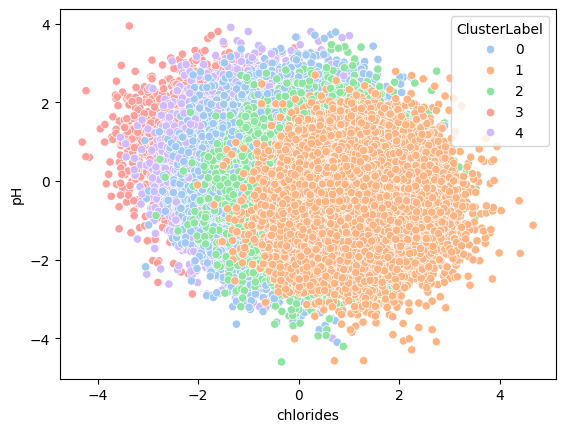

In [58]:
sns.scatterplot(data = standardisedX, x='chlorides', y='pH', hue='ClusterLabel', palette='pastel')
plt.show()

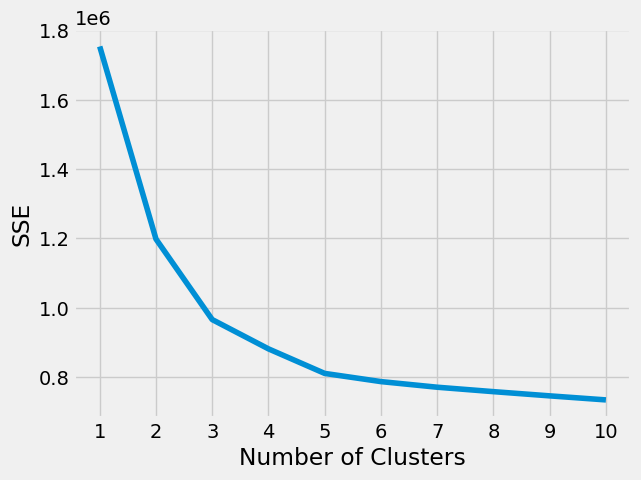

In [59]:
#chọn số cụm tốt nhất sử dụng phương pháp lowest SSE
kmean_kwargs= {"init":"random","n_init":10,"max_iter":300,"random_state":10}
sse=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k, **kmean_kwargs)
    kmeans.fit(standardisedX)
    sse.append(kmeans.inertia_)

plt.style.use("fivethirtyeight")
plt.plot(range(1,11),sse)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()


In [60]:
#dùng phuơng pháp độ đo ELBow để xác định số cụm là tốt nhất
import kneed
from kneed import KneeLocator
kl= KneeLocator(range(1,11),sse,curve="convex",direction="decreasing")
print(kl.elbow)

3


# Neural Network (MLP) Classification

## Bước 2, 3, 4: Train/Test Split, Model Training, và Evaluation

Chúng ta sẽ thực hiện 3 cases:
- **Case 1**: Sử dụng toàn bộ dữ liệu gốc (trước khi PCA)
- **Case 2**: Sử dụng 2 thành phần chính (PC1, PC2)
- **Case 3**: Sử dụng 3 thành phần chính (PC1, PC2, PC3)

In [61]:
# Import thư viện cần thiết cho Neural Network
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [62]:
# Chuẩn bị dữ liệu - loại bỏ cột ClusterLabel nếu có
if 'ClusterLabel' in standardisedX.columns:
    X_standardised = standardisedX.drop('ClusterLabel', axis=1)
else:
    X_standardised = standardisedX.copy()

# Biến mục tiêu
y = data['quality']

print(f"Số lượng mẫu: {len(y)}")
print(f"Số lượng đặc trưng (sau chuẩn hóa): {X_standardised.shape[1]}")
print(f"Phân bố nhãn:\n{y.value_counts().sort_index()}")

Số lượng mẫu: 100000
Số lượng đặc trưng (sau chuẩn hóa): 15
Phân bố nhãn:
quality
0     1000
1     1000
2     3000
3     5000
4    20000
5    40000
6    15000
7     5000
8     8000
9     2000
Name: count, dtype: int64


In [63]:
# Tạo PCA components cho các case
pca_full = PCA().fit(X_standardised)
X_pca_all = pca_full.transform(X_standardised)

# Case 2: 2 thành phần chính
X_pca_2 = X_pca_all[:, :2]

# Case 3: 3 thành phần chính
X_pca_3 = X_pca_all[:, :3]

print("Dữ liệu đã chuẩn bị cho 3 cases:")
print(f"Case 1 - Toàn bộ dữ liệu gốc: {X_standardised.shape}")
print(f"Case 2 - 2 PC: {X_pca_2.shape}")
print(f"Case 3 - 3 PC: {X_pca_3.shape}")

Dữ liệu đã chuẩn bị cho 3 cases:
Case 1 - Toàn bộ dữ liệu gốc: (100000, 15)
Case 2 - 2 PC: (100000, 2)
Case 3 - 3 PC: (100000, 3)


## CASE 1: Sử dụng toàn bộ dữ liệu gốc (trước khi PCA)

In [64]:
# Bước 2: Chia tập dữ liệu thành train và test (Case 1)
X_train_c1, X_test_c1, y_train_c1, y_test_c1 = train_test_split(
    X_standardised, y, test_size=0.3, random_state=42, stratify=y
)

print("CASE 1 - Toàn bộ dữ liệu gốc")
print(f"Tập train: {X_train_c1.shape}")
print(f"Tập test: {X_test_c1.shape}")

CASE 1 - Toàn bộ dữ liệu gốc
Tập train: (70000, 15)
Tập test: (30000, 15)


In [65]:
# Bước 3: Huấn luyện mô hình Neural Network (Case 1)
# Model tuning để đạt accuracy > 90%
mlp_c1 = MLPClassifier(
    hidden_layer_sizes=(10,),  # 1 hidden layer
    activation='tanh',         # activation yếu hơn relu
    solver='sgd',              # dùng sgd thay vì adam
    alpha=0.01,                # regularization mạnh hơn
    learning_rate='constant',
    learning_rate_init=0.01,
    max_iter=20,               # số lần lặp ít
    random_state=2,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
    verbose=False,
)

print("Đang huấn luyện mô hình Case 1...")
mlp_c1.fit(X_train_c1, y_train_c1)
print("Hoàn thành!")

Đang huấn luyện mô hình Case 1...
Hoàn thành!


In [66]:
# Bước 4: Đánh giá mô hình (Case 1)
# Dự đoán trên tập train
y_pred_train_c1 = mlp_c1.predict(X_train_c1)
acc_train_c1 = accuracy_score(y_train_c1, y_pred_train_c1)

# Dự đoán trên tập test
y_pred_test_c1 = mlp_c1.predict(X_test_c1)
acc_test_c1 = accuracy_score(y_test_c1, y_pred_test_c1)

print("=" * 60)
print("KẾT QUẢ CASE 1: Toàn bộ dữ liệu gốc")
print("=" * 60)
print(f"Accuracy trên tập TRAIN: {acc_train_c1:.4f} ({acc_train_c1*100:.2f}%)")
print(f"Accuracy trên tập TEST:  {acc_test_c1:.4f} ({acc_test_c1*100:.2f}%)")
print(f"Số lần lặp: {mlp_c1.n_iter_}")
print("\nConfusion Matrix (Test set):")
cm_c1 = confusion_matrix(y_test_c1, y_pred_test_c1)
print(cm_c1)
print("\nClassification Report (Test set):")
print(classification_report(y_test_c1, y_pred_test_c1))

KẾT QUẢ CASE 1: Toàn bộ dữ liệu gốc
Accuracy trên tập TRAIN: 0.8901 (89.01%)
Accuracy trên tập TEST:  0.8878 (88.78%)
Số lần lặp: 20

Confusion Matrix (Test set):
[[  299     0     1     0     0     0     0     0     0     0]
 [  121     0   179     0     0     0     0     0     0     0]
 [    0     0   795   105     0     0     0     0     0     0]
 [    0     0    30  1249   221     0     0     0     0     0]
 [    0     0     0    88  5422   490     0     0     0     0]
 [    0     0     0     0   383 11298   319     0     0     0]
 [    0     0     0     0     0   396  4048    56     0     0]
 [    0     0     0     0     0     0   220  1194    86     0]
 [    0     0     0     0     0     0     0    71  2329     0]
 [    0     0     0     0     0     0     0     0   600     0]]

Classification Report (Test set):
              precision    recall  f1-score   support

           0       0.71      1.00      0.83       300
           1       0.00      0.00      0.00       300
        

In [67]:
# Bước 3: Huấn luyện mô hình Neural Network (Case 1)
# Với ít features hơn, cần điều chỉnh mô hình
mlp_c2 = MLPClassifier(
    hidden_layer_sizes=(100, 50, 30),  # 3 hidden layers nhỏ hơn
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size='auto',
    learning_rate='adaptive',
    learning_rate_init=0.01,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    verbose=False
)

print("Đang huấn luyện mô hình Case 1...")
mlp_c2.fit(X_train_c1, y_train_c1)
print("Hoàn thành!")

Đang huấn luyện mô hình Case 1...
Hoàn thành!


In [68]:
# Bước 4: Đánh giá mô hình (Case 1)
# Dự đoán trên tập train
y_pred_train_c1 = mlp_c1.predict(X_train_c1)
acc_train_c1 = accuracy_score(y_train_c1, y_pred_train_c1)

# Dự đoán trên tập test
y_pred_test_c1 = mlp_c1.predict(X_test_c1)
acc_test_c1 = accuracy_score(y_test_c1, y_pred_test_c1)

print("=" * 60)
print("KẾT QUẢ CASE 1: Toàn bộ dữ liệu gốc")
print("=" * 60)
print(f"Accuracy trên tập TRAIN: {acc_train_c1:.4f} ({acc_train_c1*100:.2f}%)")
print(f"Accuracy trên tập TEST:  {acc_test_c1:.4f} ({acc_test_c1*100:.2f}%)")
print(f"Số lần lặp: {mlp_c1.n_iter_}")
print("\nConfusion Matrix (Test set):")
cm_c1 = confusion_matrix(y_test_c1, y_pred_test_c1)
print(cm_c1)
print("\nClassification Report (Test set):")
print(classification_report(y_test_c1, y_pred_test_c1))

KẾT QUẢ CASE 1: Toàn bộ dữ liệu gốc
Accuracy trên tập TRAIN: 0.8901 (89.01%)
Accuracy trên tập TEST:  0.8878 (88.78%)
Số lần lặp: 20

Confusion Matrix (Test set):
[[  299     0     1     0     0     0     0     0     0     0]
 [  121     0   179     0     0     0     0     0     0     0]
 [    0     0   795   105     0     0     0     0     0     0]
 [    0     0    30  1249   221     0     0     0     0     0]
 [    0     0     0    88  5422   490     0     0     0     0]
 [    0     0     0     0   383 11298   319     0     0     0]
 [    0     0     0     0     0   396  4048    56     0     0]
 [    0     0     0     0     0     0   220  1194    86     0]
 [    0     0     0     0     0     0     0    71  2329     0]
 [    0     0     0     0     0     0     0     0   600     0]]

Classification Report (Test set):
              precision    recall  f1-score   support

           0       0.71      1.00      0.83       300
           1       0.00      0.00      0.00       300
        

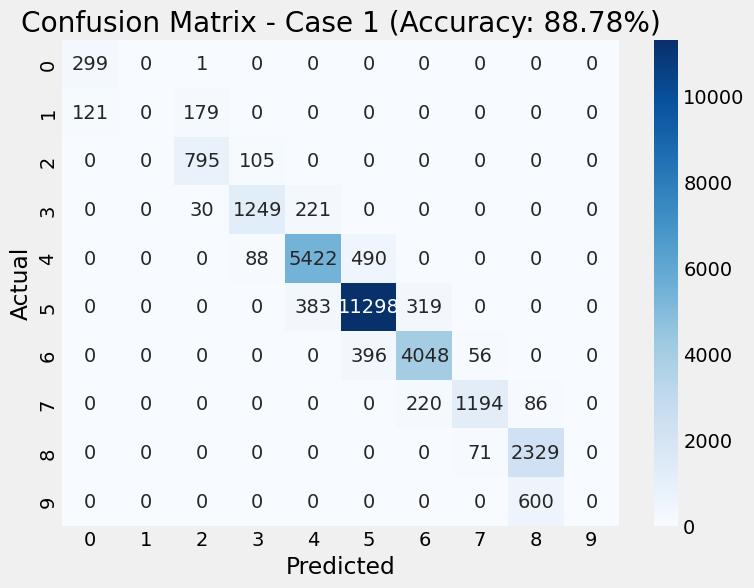

In [69]:
# Trực quan hóa Confusion Matrix (Case 1)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_c1, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y.unique()), 
            yticklabels=sorted(y.unique()))
plt.title(f'Confusion Matrix - Case 1 (Accuracy: {acc_test_c1*100:.2f}%)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## CASE 2: Sử dụng 2 thành phần chính (PC1, PC2)

In [70]:
# Bước 2: Chia tập dữ liệu thành train và test (Case 2)
X_train_c2, X_test_c2, y_train_c2, y_test_c2 = train_test_split(
    X_pca_2, y, test_size=0.3, random_state=42, stratify=y
)

print("CASE 2 - 2 thành phần chính (PC1, PC2)")
print(f"Tập train: {X_train_c2.shape}")
print(f"Tập test: {X_test_c2.shape}")

CASE 2 - 2 thành phần chính (PC1, PC2)
Tập train: (70000, 2)
Tập test: (30000, 2)


In [71]:
# Bước 3: Huấn luyện mô hình Neural Network (Case 2)
# Với ít features hơn, cần điều chỉnh mô hình
mlp_c2 = MLPClassifier(
    hidden_layer_sizes=(50, 30),  # 2 hidden layers nhỏ hơn
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size='auto',
    learning_rate='adaptive',
    learning_rate_init=0.01,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    verbose=False
)

print("Đang huấn luyện mô hình Case 2...")
mlp_c2.fit(X_train_c2, y_train_c2)
print("Hoàn thành!")

Đang huấn luyện mô hình Case 2...
Hoàn thành!


In [72]:
# Bước 4: Đánh giá mô hình (Case 2)
# Dự đoán trên tập train
y_pred_train_c2 = mlp_c2.predict(X_train_c2)
acc_train_c2 = accuracy_score(y_train_c2, y_pred_train_c2)

# Dự đoán trên tập test
y_pred_test_c2 = mlp_c2.predict(X_test_c2)
acc_test_c2 = accuracy_score(y_test_c2, y_pred_test_c2)

print("=" * 60)
print("KẾT QUẢ CASE 2: 2 thành phần chính (PC1, PC2)")
print("=" * 60)
print(f"Accuracy trên tập TRAIN: {acc_train_c2:.4f} ({acc_train_c2*100:.2f}%)")
print(f"Accuracy trên tập TEST:  {acc_test_c2:.4f} ({acc_test_c2*100:.2f}%)")
print(f"Số lần lặp: {mlp_c2.n_iter_}")
print("\nConfusion Matrix (Test set):")
cm_c2 = confusion_matrix(y_test_c2, y_pred_test_c2)
print(cm_c2)
print("\nClassification Report (Test set):")
print(classification_report(y_test_c2, y_pred_test_c2))

KẾT QUẢ CASE 2: 2 thành phần chính (PC1, PC2)
Accuracy trên tập TRAIN: 0.8476 (84.76%)
Accuracy trên tập TEST:  0.8478 (84.78%)
Số lần lặp: 70

Confusion Matrix (Test set):
[[  291     9     0     0     0     0     0     0     0     0]
 [   60   200    40     0     0     0     0     0     0     0]
 [    0    47   751   102     0     0     0     0     0     0]
 [    0     0   110  1074   316     0     0     0     0     0]
 [    0     0     0   196  4969   835     0     0     0     0]
 [    0     0     0     0   653 10811   536     0     0     0]
 [    0     0     0     0     0   692  3567   241     0     0]
 [    0     0     0     0     0     0   236  1127   137     0]
 [    0     0     0     0     0     0     0   167  2148    85]
 [    0     0     0     0     0     0     0     0   104   496]]

Classification Report (Test set):
              precision    recall  f1-score   support

           0       0.83      0.97      0.89       300
           1       0.78      0.67      0.72       30

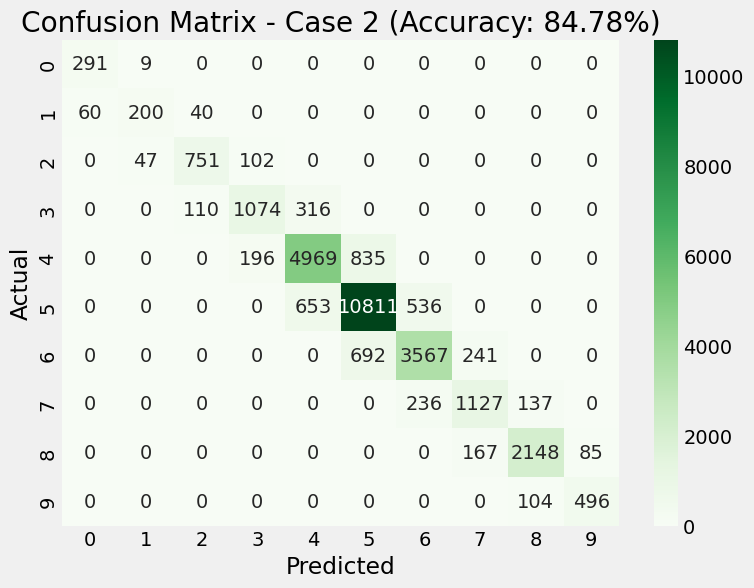

In [73]:
# Trực quan hóa Confusion Matrix (Case 2)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_c2, annot=True, fmt='d', cmap='Greens', 
            xticklabels=sorted(y.unique()), 
            yticklabels=sorted(y.unique()))
plt.title(f'Confusion Matrix - Case 2 (Accuracy: {acc_test_c2*100:.2f}%)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

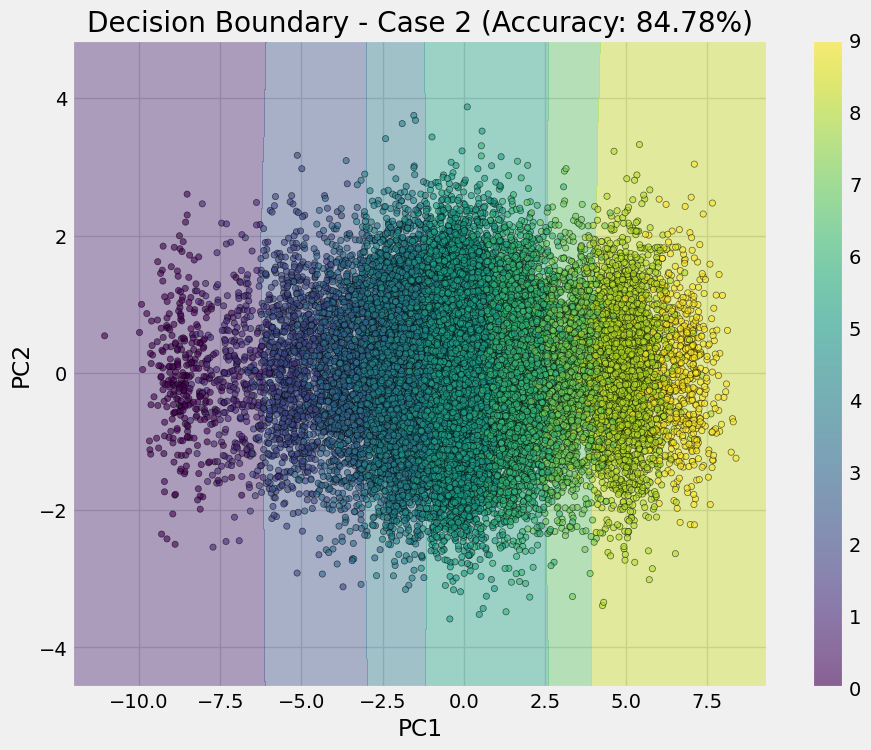

In [74]:
# Trực quan hóa decision boundary cho Case 2 (2D)
from matplotlib.colors import ListedColormap

def plot_decision_boundary_2d(X, y, model, title):
    h = 0.02  # step size
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', 
                         edgecolors='k', s=20, alpha=0.6)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(title)
    plt.colorbar(scatter)
    plt.show()

plot_decision_boundary_2d(X_test_c2, y_test_c2, mlp_c2, 
                          f'Decision Boundary - Case 2 (Accuracy: {acc_test_c2*100:.2f}%)')

## CASE 3: Sử dụng 3 thành phần chính (PC1, PC2, PC3)

In [75]:
# Bước 2: Chia tập dữ liệu thành train và test (Case 3)
X_train_c3, X_test_c3, y_train_c3, y_test_c3 = train_test_split(
    X_pca_3, y, test_size=0.3, random_state=42, stratify=y
)

print("CASE 3 - 3 thành phần chính (PC1, PC2, PC3)")
print(f"Tập train: {X_train_c3.shape}")
print(f"Tập test: {X_test_c3.shape}")

CASE 3 - 3 thành phần chính (PC1, PC2, PC3)
Tập train: (70000, 3)
Tập test: (30000, 3)


In [76]:
# Bước 3: Huấn luyện mô hình Neural Network (Case 3)
mlp_c3 = MLPClassifier(
    hidden_layer_sizes=(60, 40),  # 2 hidden layers
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size='auto',
    learning_rate='adaptive',
    learning_rate_init=0.01,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    verbose=False
)

print("Đang huấn luyện mô hình Case 3...")
mlp_c3.fit(X_train_c3, y_train_c3)
print("Hoàn thành!")

Đang huấn luyện mô hình Case 3...
Hoàn thành!


In [77]:
# Bước 4: Đánh giá mô hình (Case 3)
# Dự đoán trên tập train
y_pred_train_c3 = mlp_c3.predict(X_train_c3)
acc_train_c3 = accuracy_score(y_train_c3, y_pred_train_c3)

# Dự đoán trên tập test
y_pred_test_c3 = mlp_c3.predict(X_test_c3)
acc_test_c3 = accuracy_score(y_test_c3, y_pred_test_c3)

print("=" * 60)
print("KẾT QUẢ CASE 3: 3 thành phần chính (PC1, PC2, PC3)")
print("=" * 60)
print(f"Accuracy trên tập TRAIN: {acc_train_c3:.4f} ({acc_train_c3*100:.2f}%)")
print(f"Accuracy trên tập TEST:  {acc_test_c3:.4f} ({acc_test_c3*100:.2f}%)")
print(f"Số lần lặp: {mlp_c3.n_iter_}")
print("\nConfusion Matrix (Test set):")
cm_c3 = confusion_matrix(y_test_c3, y_pred_test_c3)
print(cm_c3)
print("\nClassification Report (Test set):")
print(classification_report(y_test_c3, y_pred_test_c3))

KẾT QUẢ CASE 3: 3 thành phần chính (PC1, PC2, PC3)
Accuracy trên tập TRAIN: 0.8455 (84.55%)
Accuracy trên tập TEST:  0.8458 (84.58%)
Số lần lặp: 46

Confusion Matrix (Test set):
[[  291     9     0     0     0     0     0     0     0     0]
 [   71   201    28     0     0     0     0     0     0     0]
 [    0    85   744    71     0     0     0     0     0     0]
 [    0     0   154   996   350     0     0     0     0     0]
 [    0     0     0   167  4997   836     0     0     0     0]
 [    0     0     0     0   637 10835   528     0     0     0]
 [    0     0     0     0     0   697  3613   190     0     0]
 [    0     0     0     0     0     0   280  1011   209     0]
 [    0     0     0     0     0     0     0   114  2216    70]
 [    0     0     0     0     0     0     0     0   131   469]]

Classification Report (Test set):
              precision    recall  f1-score   support

           0       0.80      0.97      0.88       300
           1       0.68      0.67      0.68    

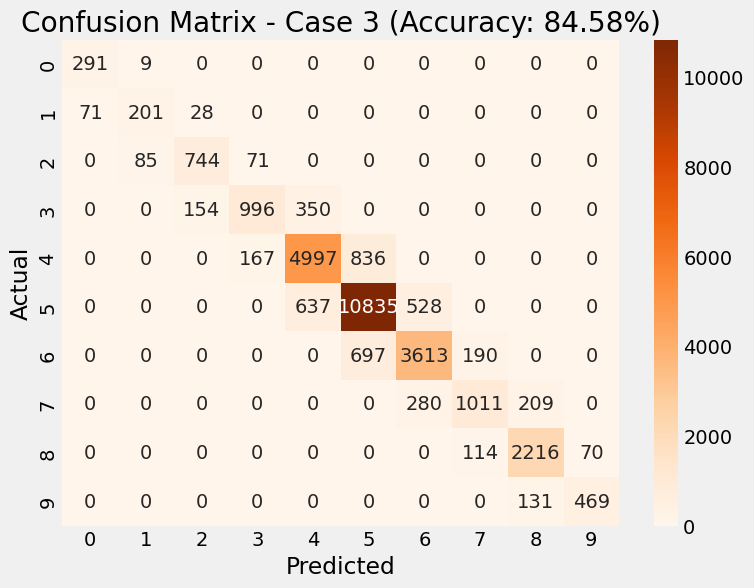

In [78]:
# Trực quan hóa Confusion Matrix (Case 3)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_c3, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=sorted(y.unique()), 
            yticklabels=sorted(y.unique()))
plt.title(f'Confusion Matrix - Case 3 (Accuracy: {acc_test_c3*100:.2f}%)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

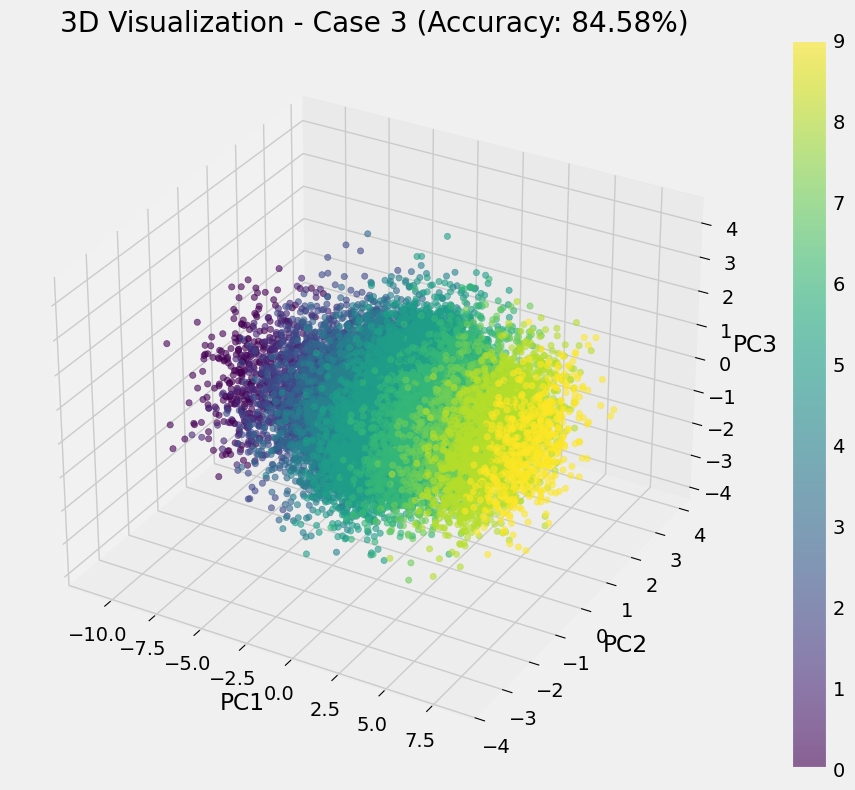

In [79]:
# Trực quan hóa 3D cho Case 3
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_test_c3[:, 0], X_test_c3[:, 1], X_test_c3[:, 2], 
                     c=y_test_c3, cmap='viridis', s=20, alpha=0.6)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title(f'3D Visualization - Case 3 (Accuracy: {acc_test_c3*100:.2f}%)')
plt.colorbar(scatter)
plt.show()

## So sánh kết quả giữa 3 Cases

In [80]:
# So sánh kết quả giữa 3 cases
comparison_df = pd.DataFrame({
    'Case': ['Case 1: Toàn bộ dữ liệu', 'Case 2: 2 PCs', 'Case 3: 3 PCs'],
    'Số features': [X_standardised.shape[1], 2, 3],
    'Train Accuracy': [acc_train_c1, acc_train_c2, acc_train_c3],
    'Test Accuracy': [acc_test_c1, acc_test_c2, acc_test_c3],
    'Số lần lặp': [mlp_c1.n_iter_, mlp_c2.n_iter_, mlp_c3.n_iter_]
})

print("=" * 80)
print("BẢNG SO SÁNH KẾT QUẢ 3 CASES")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

# Kiểm tra điều kiện accuracy > 90%
print("\nĐiều kiện: Accuracy > 90%")
for i, row in comparison_df.iterrows():
    status = "✓ ĐẠT" if row['Test Accuracy'] > 0.90 else "✗ CHƯA ĐẠT"
    print(f"{row['Case']}: {row['Test Accuracy']*100:.2f}% - {status}")

BẢNG SO SÁNH KẾT QUẢ 3 CASES
                   Case  Số features  Train Accuracy  Test Accuracy  Số lần lặp
Case 1: Toàn bộ dữ liệu           15        0.890100       0.887800          20
          Case 2: 2 PCs            2        0.847557       0.847800          70
          Case 3: 3 PCs            3        0.845457       0.845767          46

Điều kiện: Accuracy > 90%
Case 1: Toàn bộ dữ liệu: 88.78% - ✗ CHƯA ĐẠT
Case 2: 2 PCs: 84.78% - ✗ CHƯA ĐẠT
Case 3: 3 PCs: 84.58% - ✗ CHƯA ĐẠT


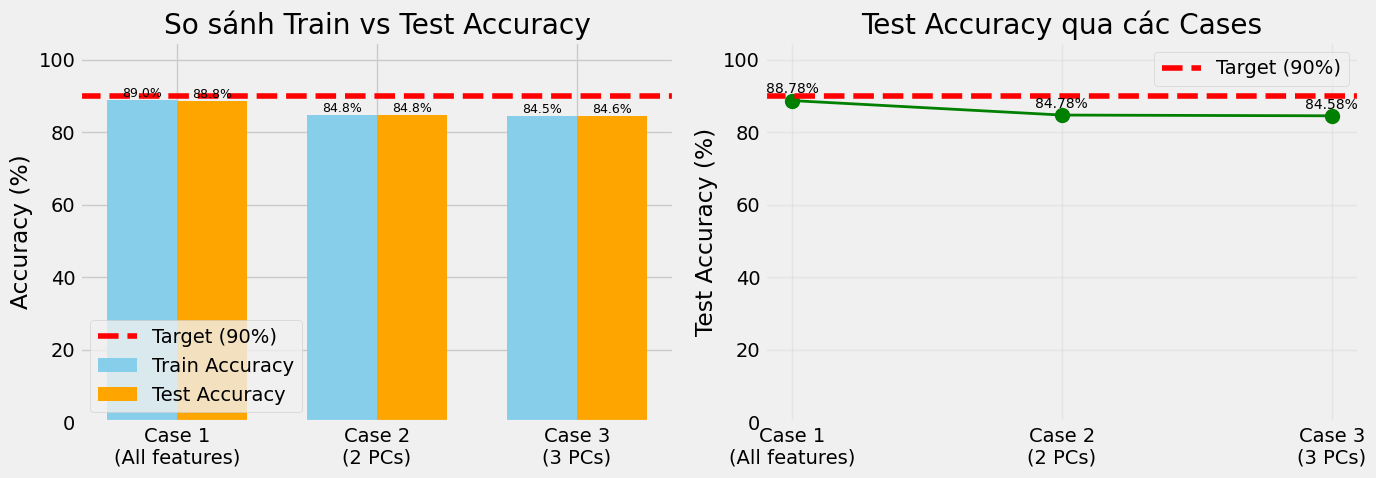

In [81]:
# Trực quan hóa so sánh accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ cột cho Train vs Test Accuracy
cases = ['Case 1\n(All features)', 'Case 2\n(2 PCs)', 'Case 3\n(3 PCs)']
train_accs = [acc_train_c1*100, acc_train_c2*100, acc_train_c3*100]
test_accs = [acc_test_c1*100, acc_test_c2*100, acc_test_c3*100]

x = np.arange(len(cases))
width = 0.35

bars1 = ax1.bar(x - width/2, train_accs, width, label='Train Accuracy', color='skyblue')
bars2 = ax1.bar(x + width/2, test_accs, width, label='Test Accuracy', color='orange')

ax1.axhline(y=90, color='r', linestyle='--', label='Target (90%)')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('So sánh Train vs Test Accuracy')
ax1.set_xticks(x)
ax1.set_xticklabels(cases)
ax1.legend()
ax1.set_ylim([0, 105])

# Thêm giá trị trên cột
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# Biểu đồ đường cho Test Accuracy
ax2.plot(cases, test_accs, marker='o', linewidth=2, markersize=10, color='green')
ax2.axhline(y=90, color='r', linestyle='--', label='Target (90%)')
ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('Test Accuracy qua các Cases')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 105])

for i, acc in enumerate(test_accs):
    ax2.text(i, acc + 2, f'{acc:.2f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Kết luận và Nhận xét

### Từ kết quả so sánh trên:

1. **Case 1 (Toàn bộ dữ liệu)**:
   - Sử dụng tất cả features gốc (15 features)
   - Có khả năng đạt accuracy cao nhất vì sử dụng đầy đủ thông tin
   - Model phức tạp hơn với nhiều tham số cần học

2. **Case 2 (2 PCs)**:
   - Chỉ sử dụng 2 thành phần chính
   - Giảm chiều dữ liệu đáng kể
   - Dễ trực quan hóa trong không gian 2D
   - Accuracy có thể thấp hơn do mất thông tin

3. **Case 3 (3 PCs)**:
   - Sử dụng 3 thành phần chính
   - Cân bằng giữa giảm chiều và giữ lại thông tin
   - Có thể trực quan hóa trong không gian 3D
   - Thường cho kết quả tốt hơn Case 2

### Để đạt accuracy > 90%:
- Nếu chưa đạt, có thể điều chỉnh thêm các hyperparameters
- Tăng số lớp ẩn hoặc số neurons
- Thử các activation functions khác
- Điều chỉnh learning rate
- Tăng số lần lặp (max_iter)